# Sklearn

## sklearn.liner_model

**linear_model:**
* RidgeClassifier
* SGDClassifier
* SGDRegressor
* LinearRegression
* LogisticRegression
* Lasso
* etc

Документация: https://scikit-learn.ru/stable/modules/linear_model.html



In [4]:
from sklearn import model_selection, datasets, linear_model, metrics
import matplotlib.pyplot as plt
import numpy as np

### Генерация данных

In [32]:
blobs = datasets.make_blobs(n_samples=200, centers=2, cluster_std=5.5, random_state=1)

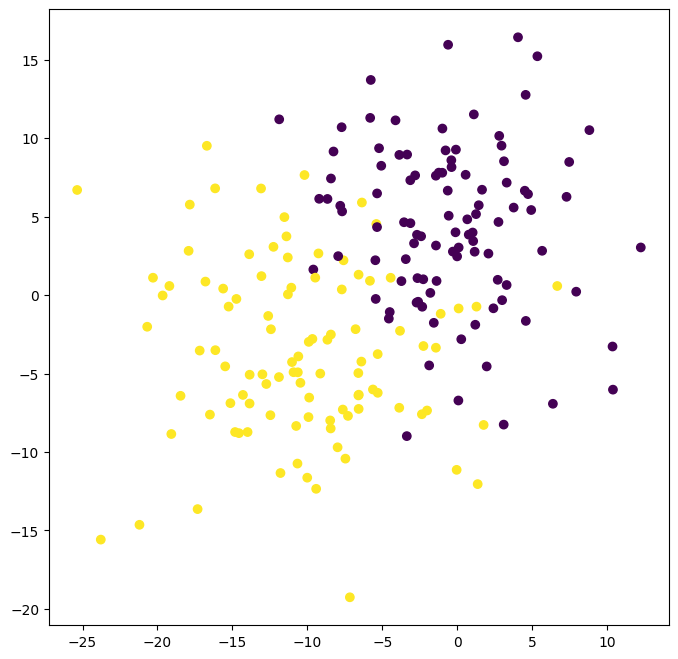

In [33]:
plt.figure(figsize=(8, 8))
plt.scatter(blobs[0][:, 0], blobs[0][:, 1], c=blobs[1])

In [34]:
train_data, test_data, train_labels, test_labels = model_selection.train_test_split(blobs[0], blobs[1], 
                                                                                    test_size = 0.3,
                                                                                    random_state = 1)

### Линейная классификация

#### RidgeClassifier

In [35]:
#создание объекта - классификатора
ridge_classifier = linear_model.RidgeClassifier(random_state = 1)

In [36]:
#обучение классификатора
ridge_classifier.fit(train_data, train_labels)

,"alpha alpha: float, default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If set to false, nointercept will be used in calculations (e.g. data is expected to bealready centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.The default value is determined by scipy.sparse.linalg.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard scipy.linalg.solve function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in scipy.sparse.linalg.cg. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine scipy.sparse.linalg.lsqr. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its unbiased and more flexible version named SAGA. Both methods use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from sklearn.preprocessing. .. versionadded:: 0.17 Stochastic Average Gradient descent solver. .. versionadded:: 0.19 SAGA solver.- 'lbfgs' uses L-BFGS-B algorithm implemented in `scipy.optimize.minimize`. It can be used only when `positive` is True.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details.",1


In [37]:
#применение обученного классификатора
ridge_predictions = ridge_classifier.predict(test_data)

In [38]:
print(test_labels)

[0 0 1 0 0 1 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 0 1 0 0 1 0
 1 1 0 0 0 0 1 0 1 0 1 1 0 1 0 1 0 1 1 1 0 0 0]


In [39]:
print(ridge_predictions)

[0 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 1 1 0 1 1 1 1 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 1 0 1 0 1 1 0 0 0 1 0 1 0 1 0 0 0]


In [40]:
#оценка качества классификации
metrics.accuracy_score(test_labels, ridge_predictions)

0.85

In [41]:
ridge_classifier.coef_

array([-0.08379318, -0.04848707])

In [42]:
ridge_classifier.intercept_ 

array([-0.47479054])

#### LogisticRegression

In [43]:
log_regressor = linear_model.LogisticRegression(random_state = 1)

In [44]:
log_regressor.fit(train_data, train_labels)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [45]:
lr_predictions = log_regressor.predict(test_data)

In [46]:
lr_proba_predictions = log_regressor.predict_proba(test_data)

In [47]:
print(test_labels)

[0 0 1 0 0 1 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 0 1 0 0 1 0
 1 1 0 0 0 0 1 0 1 0 1 1 0 1 0 1 0 1 1 1 0 0 0]


In [48]:
print(lr_predictions)

[0 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 1 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 1 0 1 0 1 1 0 1 0 1 0 1 0 1 0 0 0]


In [49]:
print(lr_proba_predictions)

[[9.84984021e-01 1.50159793e-02]
 [7.37043147e-01 2.62956853e-01]
 [4.63203289e-02 9.53679671e-01]
 [8.59176776e-01 1.40823224e-01]
 [9.96241364e-01 3.75863573e-03]
 [1.39731174e-02 9.86026883e-01]
 [6.23372555e-02 9.37662745e-01]
 [9.52513393e-01 4.74866068e-02]
 [8.51483999e-01 1.48516001e-01]
 [9.99576271e-01 4.23729115e-04]
 [8.25600042e-01 1.74399958e-01]
 [9.98361442e-01 1.63855775e-03]
 [6.99045840e-06 9.99993010e-01]
 [9.99306713e-01 6.93287342e-04]
 [9.41774104e-01 5.82258961e-02]
 [6.60198603e-01 3.39801397e-01]
 [3.42584898e-04 9.99657415e-01]
 [9.99831416e-01 1.68584442e-04]
 [4.62631059e-01 5.37368941e-01]
 [6.04370077e-04 9.99395630e-01]
 [4.81659126e-03 9.95183409e-01]
 [6.40745865e-03 9.93592541e-01]
 [3.45678341e-04 9.99654322e-01]
 [9.77027103e-01 2.29728972e-02]
 [1.47711171e-02 9.85228883e-01]
 [1.56025698e-04 9.99843974e-01]
 [4.60361946e-03 9.95396381e-01]
 [5.69188484e-03 9.94308115e-01]
 [7.52089950e-01 2.47910050e-01]
 [5.23887681e-01 4.76112319e-01]
 [9.994929

In [50]:
metrics.accuracy_score(test_labels, lr_predictions)

0.85

In [51]:
metrics.accuracy_score(test_labels, ridge_predictions)

0.85

### Оценка качества по cross-validation

#### cross_val_score

In [52]:
ridge_scoring = model_selection.cross_val_score(ridge_classifier, blobs[0], blobs[1], scoring = 'accuracy', cv = 10)

In [53]:
lr_scoring = model_selection.cross_val_score(log_regressor, blobs[0], blobs[1], scoring = 'accuracy', cv = 10)

In [57]:
ridge_scoring

array([0.95, 0.8 , 0.9 , 0.95, 0.85, 1.  , 0.9 , 1.  , 0.9 , 0.85])

In [58]:
lr_scoring

array([0.95, 0.8 , 0.9 , 0.95, 0.85, 1.  , 0.85, 1.  , 0.85, 0.85])

In [ ]:
print(f'Ridge mean:{ridge_scoring.mean()}, max:{ridge_scoring.max()}, min:{ridge_scoring.min()}, std:{ridge_scoring.min()}')

Ridge mean:0.9099999999999999, max:1.0, min:0.8, std:0.8


In [59]:
print(f'Log mean:{lr_scoring.mean()}, max:{lr_scoring.max()}, min:{lr_scoring.min()}, std:{lr_scoring.min()}')

Log mean:0.9, max:1.0, min:0.8, std:0.8


#### cross_val_score с заданными scorer и cv_strategy

In [60]:
scorer = metrics.make_scorer(metrics.accuracy_score)

In [61]:
cv_strategy = model_selection.StratifiedShuffleSplit(n_splits=10, test_size=0.3, random_state=2)

In [62]:
ridge_scoring = model_selection.cross_val_score(ridge_classifier, blobs[0], blobs[1], scoring=scorer, cv=cv_strategy)

In [63]:
lr_scoring = model_selection.cross_val_score(log_regressor, blobs[0], blobs[1], scoring=scorer, cv=cv_strategy)

In [64]:
print(f'Ridge mean:{ridge_scoring.mean()}, max:{ridge_scoring.max()}, min:{ridge_scoring.min()}, std:{ridge_scoring.min()}')

Ridge mean:0.9199999999999999, max:0.9833333333333333, min:0.8666666666666667, std:0.8666666666666667


In [65]:
print(f'Log mean:{lr_scoring.mean()}, max:{lr_scoring.max()}, min:{lr_scoring.min()}, std:{lr_scoring.min()}')

Log mean:0.9216666666666666, max:0.9666666666666667, min:0.8666666666666667, std:0.8666666666666667
